# Risk Aversion and the Value of Insurance

This notebook uses a simple insurance decision to illustrate **expected utility**, **constant relative risk aversion (CRRA)**, **certainty equivalents**, and the **risk premium**.

The central question is:

> How much would a person with CRRA preferences be willing to pay to eliminate a small probability of a large financial loss?

We will use the answer to infer an approximate coefficient of relative risk aversion, $\rho$.

## 1. CRRA utility

For consumption (or wealth) $c>0$, CRRA utility is

$$
u(c;\rho)=
\begin{cases}
\dfrac{c^{1-\rho}-1}{1-\rho}, & \rho\neq 1,\$$6pt]
\log c, & \rho=1.
\end{cases}
$$

The parameter $\rho$ is the coefficient of **relative risk aversion**:

$$
-\frac{c u''(c)}{u'(c)}=\rho.
$$

Thus $\rho=0$ corresponds to risk neutrality, $\rho>0$ to risk aversion, and larger values of $\rho$ imply greater aversion to proportional risks.

The subtraction of 1 in the numerator is only a normalization; it does not affect choices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def crra_utility(c, rho):
    """CRRA utility, with the logarithmic case handled at rho = 1."""
    c = np.asarray(c, dtype=float)
    if np.any(c <= 0):
        raise ValueError("CRRA utility requires positive consumption or wealth.")
    if np.isclose(rho, 1.0):
        return np.log(c)
    return (c**(1 - rho) - 1) / (1 - rho)

## 2. The certainty equivalent

Suppose a risky prospect has expected utility $EU$. Its **certainty equivalent** $CE$ is the sure amount satisfying

$$
u(CE;\rho)=EU.
$$

Inverting CRRA utility gives

$$
CE=
\begin{cases}
\left[1+(1-\rho)EU\right]^{1/(1-\rho)}, & \rho\neq1,\\[6pt]
e^{EU}, & \rho=1.
\end{cases}
$$

The certainty equivalent converts utility units back into dollars, making the economic interpretation much easier.

In [3]:
def certainty_equivalent(expected_utility, rho):
    """Invert CRRA utility to obtain the certainty equivalent."""
    if np.isclose(rho, 1.0):
        return np.exp(expected_utility)
    inside = 1 + (1 - rho) * expected_utility
    if inside <= 0:
        raise ValueError("Expected utility is outside the inverse CRRA domain.")
    return inside**(1 / (1 - rho))

## 3. A simple collision-risk example

Consider an individual with annual resources of $30,000. 

There is a 5% probability of an accident that causes a $10,000 loss.

Without insurance,

$$
C=
\begin{cases}
20{,}000 & \text{with probability }0.05,\\
30{,}000 & \text{with probability }0.95.
\end{cases}
$$

Expected utility is

$$
EU(\rho)=0.05\,u(20{,}000;\rho)+0.95\,u(30{,}000;\rho).
$$

If full insurance eliminates the loss for a premium $P$, resources become $30{,}000-P$ with certainty. The maximum premium satisfies

$$
u(30{,}000-P;\rho)=EU(\rho),
$$

so

$$
P(\rho)=30{,}000-CE(\rho).
$$

This premium contains both the **actuarially fair expected loss** and an additional amount reflecting risk aversion.

In [4]:
loss = 10_000
base = 30_000
p_loss = 0.05

expected_loss = p_loss * loss

print(f"Resources without an accident: ${base:,.0f}")
print(f"Resources after an accident:   ${base-loss:,.0f}")
print(f"Probability of accident:       {p_loss:.0%}")
print(f"Expected monetary loss:        ${expected_loss:,.0f}")

Resources without an accident: $30,000
Resources after an accident:   $20,000
Probability of accident:       5%
Expected monetary loss:        $500


## 4. Willingness to pay for insurance

For each value of $\rho$, calculate expected utility without insurance, convert it to a certainty equivalent, and then find the maximum premium for complete insurance.

When $\rho=0$, the individual is risk neutral, so willingness to pay equals the expected loss: **$500**. For $\rho>0$, willingness to pay exceeds $500$.

In [5]:
def max_insurance_premium(rho, base=base, loss=loss, p_loss=p_loss):
    """Maximum premium for full insurance against the specified loss."""
    eu = (p_loss * crra_utility(base - loss, rho)
          + (1 - p_loss) * crra_utility(base, rho))
    ce = certainty_equivalent(eu, rho)
    return base - ce

rho_grid = np.linspace(0, 4, 81)
premiums = np.array([max_insurance_premium(rho) for rho in rho_grid])

for rho in [0, 0.5, 1, 2, 3, 4]:
    print(f"rho = {rho:>3}: maximum premium = ${max_insurance_premium(rho):,.2f}")

rho =   0: maximum premium = $500.00
rho = 0.5: maximum premium = $547.98
rho =   1: maximum premium = $602.07
rho =   2: maximum premium = $731.71
rho =   3: maximum premium = $895.72
rho =   4: maximum premium = $1,069.97


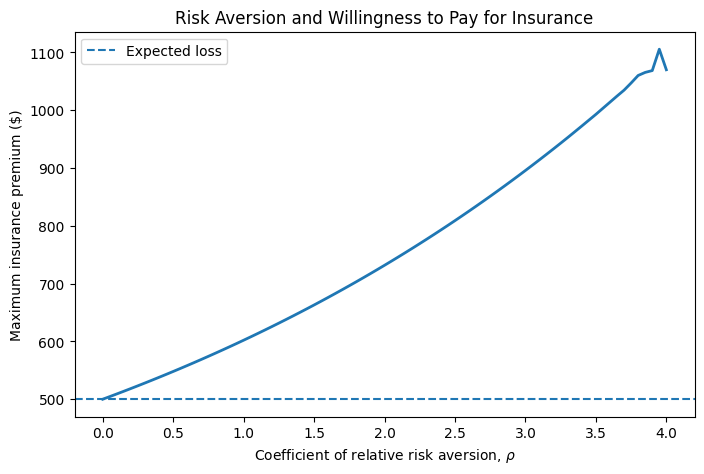

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(rho_grid, premiums, linewidth=2)
plt.axhline(expected_loss, linestyle="--", label="Expected loss")
plt.xlabel(r"Coefficient of relative risk aversion, $\rho$")
plt.ylabel("Maximum insurance premium ($)")
plt.title("Risk Aversion and Willingness to Pay for Insurance")
plt.legend()
plt.show()

## 5. Infer $\rho$ from stated willingness to pay

Now turn the exercise around. Ask how much the student would be willing to pay for the collision coverage and find the value of $\rho$ whose predicted premium is closest to that answer.

This is a **calibration exercise**, not a precise psychological measurement. The inferred value depends on the assumed wealth measure, the loss and its probability, CRRA utility, and the assumption that the only relevant uncertainty is the monetary loss described here.

The actuarially fair premium is

$$
E[L]=0.05(10{,}000)=\$500.
$$

A stated willingness to pay below $500$ cannot be rationalized by positive CRRA risk aversion in this simple model.

In [7]:
print("Suppose you have annual resources of $30,000.")
print("You have received a valuable car and are considering collision coverage.")
print("There is a 5% chance of an accident that would cost you $10,000.")
print("The policy completely eliminates that $10,000 loss.")
print()
print("What is the MOST you would be willing to pay for the policy for one year?")

payment = float(input("Maximum premium ($): "))

distance = np.abs(premiums - payment)
idx = np.argmin(distance)
rho_hat = rho_grid[idx]
model_premium = premiums[idx]

print()
print(f"Actuarially fair premium: ${expected_loss:,.2f}")
print(f"Closest CRRA coefficient: rho ≈ {rho_hat:.2f}")
print(f"Premium predicted at that rho: ${model_premium:,.2f}")

if payment < expected_loss:
    print("\nThe stated premium is below the expected loss. "
          "Within this model it cannot be matched by rho >= 0.")

Suppose you have annual resources of $30,000.
You have received a valuable car and are considering collision coverage.
There is a 5% chance of an accident that would cost you $10,000.
The policy completely eliminates that $10,000 loss.

What is the MOST you would be willing to pay for the policy for one year?


ValueError: could not convert string to float: ''

## 6. Economic interpretation

The **expected loss** is $500$. The amount

$$
P(\rho)-E[L]
$$

is the extra amount the individual is willing to pay **above the actuarially fair premium** to eliminate risk. It isolates the monetary effect of risk aversion in this example.

### Questions for discussion

1. Why does the maximum insurance premium rise with $\rho$?
2. Why does a risk-neutral person pay no more than the expected loss?
3. How would willingness to pay change if the accident probability doubled?
4. Would the inferred $\rho$ change if the same dollar loss were faced by someone with much greater wealth?
5. What assumptions make it problematic to interpret this exercise as a literal estimate of a person's true risk-aversion coefficient?

## 7. Optional extension: the risk loading

Plot

$$
\text{Risk loading}=P(\rho)-E[L].
$$

This separates willingness to pay for eliminating **uncertainty** from the expected monetary cost of the accident itself.

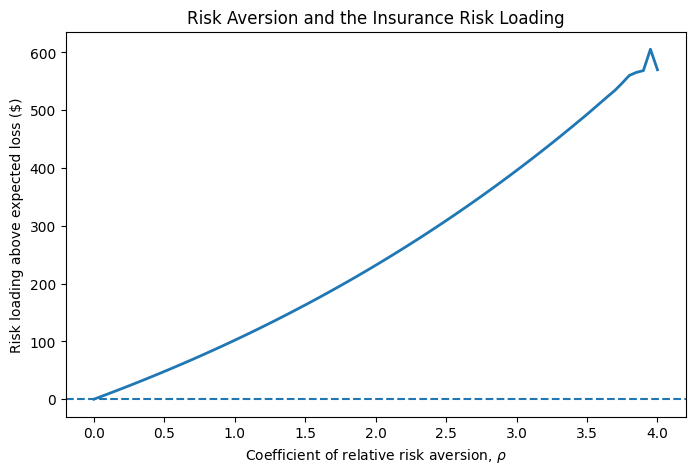

In [ ]:
risk_loading = premiums - expected_loss

plt.figure(figsize=(8, 5))
plt.plot(rho_grid, risk_loading, linewidth=2)
plt.axhline(0, linestyle="--")
plt.xlabel(r"Coefficient of relative risk aversion, $\rho$")
plt.ylabel("Risk loading above expected loss ($)")
plt.title("Risk Aversion and the Insurance Risk Loading")
plt.show()